In [63]:
!pip install wordcloud matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 5.7 MB/s  0:00:00


In [93]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd
import re
import os

In [94]:
# Stopwords
stopwords = {
    "the", "and", "for", "with", "that", "this",
    "from", "are", "was", "were", "have", "has",
    "had", "you", "your", "not", "but", "all",
    "can", "will", "into", "about", "they",
    "their", "there", "what", "when", "where",
    "which", "while", "who", "how", "why",
    "use", "using"
}

def create_wordcloud(coluna_texto,coluna_target,stopwords,df):

    for solution_type, grupo in df.groupby(coluna_target):

        # Junta textos
        texto = " ".join(
            grupo[coluna_texto]
            .dropna()
            .astype(str)
            .str.lower()
        )

        # Extrai palavras
        palavras = re.findall(r'\b[a-z]+\b', texto)

        # Filtra
        palavras_filtradas = [
            p for p in palavras
            if p not in stopwords and len(p) > 2
        ]

        # Conta frequência
        frequencia = Counter(palavras_filtradas)

        # Cria nuvem
        wordcloud = WordCloud(
            width=1200,
            height=600,
            background_color="white"
        ).generate_from_frequencies(frequencia)

        # Plot
        plt.figure(figsize=(14, 7))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")

        plt.title(
            f"Word Cloud - {solution_type}",
            fontsize=18
        )

        plt.show()


def create_txt_words(coluna_texto,coluna_target,stopwords,df,output_dir):
    
    os.makedirs(output_dir, exist_ok=True)

    for solution_type, grupo in df.groupby(coluna_target):

        # Junta textos
        texto = " ".join(
            grupo[coluna_texto]
            .dropna()
            .astype(str)
            .str.lower()
        )

        # Extrai palavras
        palavras = re.findall(r'\b[a-z]+\b', texto)

        # Filtra
        palavras_filtradas = [
            p for p in palavras
            if p not in stopwords and len(p) > 2
        ]

        # Salva TXT
        with open(f"{output_dir}/{solution_type}.txt", "w") as f:
            f.write(" ".join(palavras_filtradas))

In [95]:
df = pd.read_csv("/home/alcantara/Área de Trabalho/unipampa/quali/vunerabilidades_classificao/10_openvas_experiments_dataset.csv", encoding="latin-1")
df.head()

,IP,Hostname,Port,Port Protocol,CVSS,Severity,QoD,Solution Type,Solution,NVT Name,Summary,Specific Result,Impact,Affected Software/OS,Vulnerability Insight,Product Detection Result,CVEs,Timestamp,Result ID
0,172.31.1.107,sqli.trabalho_vulnnet,80.0,tcp,10.0,Critical,30,VendorFix,Update the PHP version on the remote host to a...,PHP End of Life (EOL) Detection - Linux,The PHP version on the remote host has reached...,"The ""PHP"" version on the remote host has reach...",An EOL version of PHP is not receiving any sec...,NaN,Each release branch of PHP is fully supported ...,Product: cpe:/a:php:php:5.5.9\nMethod: PHP Det...,NaN,2026-01-26T05:24:14Z,306b7c0f-b614-4fe8-93a0-7ab5645781eb
1,172.31.1.107,sqli.trabalho_vulnnet,80.0,tcp,9.8,Critical,30,VendorFix,"Update to version 5.5.37, 5.6.23 or later.","PHP < 5.5.37, 5.6.x < 5.6.23 Multiple Vulnerab...",PHP is prone to multiple vulnerabilities.,Installed version: 5.5.9\nFixed version: 5...,Successfully exploiting these issues allow rem...,PHP prior to version 5.5.37 and 5.6.x prior to...,The following flaws exist:\n\n - The 'spl_arr...,Product: cpe:/a:php:php:5.5.9\nMethod: PHP Det...,"CVE-2016-5770,CVE-2016-5771",2026-01-26T05:24:14Z,6929e48a-9ac4-47e2-9b8f-91a4db3b05b9
2,172.31.1.107,sqli.trabalho_vulnnet,80.0,tcp,9.8,Critical,30,VendorFix,"Update to version 5.6.40, 7.1.16, 7.2.14, 7.3....",PHP Multiple Vulnerabilities (Feb 2019) - Linux,PHP is prone to multiple vulnerabilities.,Installed version: 5.5.9\nFixed version: 5...,NaN,"PHP versions before 5.6.40, 7.x before 7.1.26,...",The following flaws exist:\n\n - Fixed bug #7...,Product: cpe:/a:php:php:5.5.9\nMethod: PHP Det...,"CVE-2016-10166,CVE-2019-6977,CVE-2019-9020,CVE...",2026-01-26T05:24:14Z,54ae23cd-fbc7-4f8a-9d6c-60a6462d3030
3,172.31.1.107,sqli.trabalho_vulnnet,80.0,tcp,9.8,Critical,30,VendorFix,"Update to version 8.1.29, 8.2.20, 8.3.8 or later.","PHP < 8.1.29, 8.2.x < 8.2.20, 8.3.x < 8.3.8 Mu...",PHP is prone to multiple vulnerabilities.,Installed version: 5.5.9\nFixed version: 8...,NaN,"PHP prior to version 8.1.29, version 8.2.x thr...",The following vulnerabilities exist:\n\n - CV...,Product: cpe:/a:php:php:5.5.9\nMethod: PHP Det...,"CVE-2024-4577,CVE-2024-5458,CVE-2024-5585",2026-01-26T05:24:14Z,8e61207d-677c-42b4-aaf9-4f92666a0239
4,172.31.1.107,sqli.trabalho_vulnnet,80.0,tcp,9.8,Critical,30,VendorFix,"Update to version 5.6.29, 7.0.14 or later.","PHP < 5.6.29, 7.0.x < 7.0.14 DoS Vulnerability...",PHP is prone to a denial of service (DoS) vuln...,Installed version: 5.5.9\nFixed version: 5...,NaN,PHP versions prior to 5.6.29 and 7.0.x prior t...,The php_wddx_push_element function in ext/wddx...,Product: cpe:/a:php:php:5.5.9\nMethod: PHP Det...,CVE-2016-9935,2026-01-26T05:24:14Z,79158e9c-459b-4005-a4a8-3442280c5fbe


In [96]:
df.columns.tolist()

['IP',
 'Hostname',
 'Port',
 'Port Protocol',
 'CVSS',
 'Severity',
 'QoD',
 'Solution Type',
 'Solution',
 'NVT Name',
 'Summary',
 'Specific Result',
 'Impact',
 'Affected Software/OS',
 'Vulnerability Insight',
 'Product Detection Result',
 'CVEs',
 'Timestamp',
 'Result ID']

In [97]:
df.isna().sum()

IP                          0
Hostname                    0
Port                        0
Port Protocol               0
CVSS                        0
Severity                    0
QoD                         0
Solution Type               0
Solution                    0
NVT Name                    0
Summary                     0
Specific Result             0
Impact                      7
Affected Software/OS        1
Vulnerability Insight       0
Product Detection Result    0
CVEs                        1
Timestamp                   0
Result ID                   0
dtype: int64

### **Experimento 1**

In [98]:
columns_base = ["NVT Name", "Summary", "Vulnerability Insight", "Impact"]
target = "Severity"
id = "Result ID"

df_experiment_1 = df[columns_base + [target, id]].copy()
df_experiment_1.rename(columns={target: "target", id: "id"}, inplace=True)
df_experiment_1.head()

,NVT Name,Summary,Vulnerability Insight,Impact,target,id
0,PHP End of Life (EOL) Detection - Linux,The PHP version on the remote host has reached...,Each release branch of PHP is fully supported ...,An EOL version of PHP is not receiving any sec...,Critical,306b7c0f-b614-4fe8-93a0-7ab5645781eb
1,"PHP < 5.5.37, 5.6.x < 5.6.23 Multiple Vulnerab...",PHP is prone to multiple vulnerabilities.,The following flaws exist:\n\n - The 'spl_arr...,Successfully exploiting these issues allow rem...,Critical,6929e48a-9ac4-47e2-9b8f-91a4db3b05b9
2,PHP Multiple Vulnerabilities (Feb 2019) - Linux,PHP is prone to multiple vulnerabilities.,The following flaws exist:\n\n - Fixed bug #7...,NaN,Critical,54ae23cd-fbc7-4f8a-9d6c-60a6462d3030
3,"PHP < 8.1.29, 8.2.x < 8.2.20, 8.3.x < 8.3.8 Mu...",PHP is prone to multiple vulnerabilities.,The following vulnerabilities exist:\n\n - CV...,NaN,Critical,8e61207d-677c-42b4-aaf9-4f92666a0239
4,"PHP < 5.6.29, 7.0.x < 7.0.14 DoS Vulnerability...",PHP is prone to a denial of service (DoS) vuln...,The php_wddx_push_element function in ext/wddx...,NaN,Critical,79158e9c-459b-4005-a4a8-3442280c5fbe


In [99]:
df_experiment_1.isna().sum()

NVT Name                 0
Summary                  0
Vulnerability Insight    0
Impact                   7
target                   0
id                       0
dtype: int64

In [100]:
path_experimento_1 = "/home/alcantara/Área de Trabalho/unipampa/quali/vunerabilidades_classificao/experimento_1/data/data_1.csv"
df_experiment_1.to_csv(path_experimento_1, index=False)

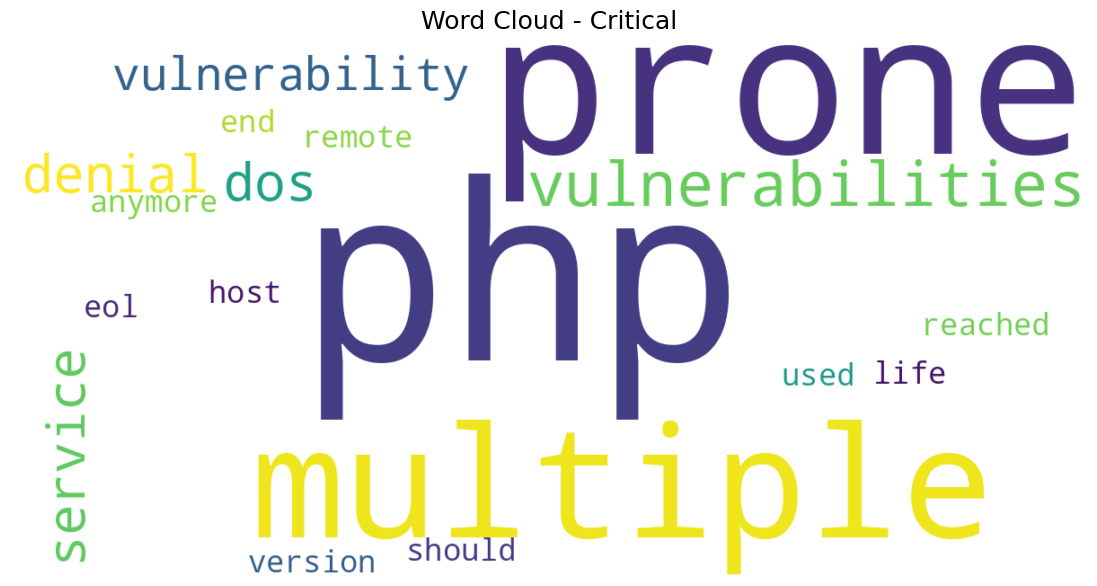

In [101]:
create_wordcloud("Summary","target",stopwords,df_experiment_1)

In [103]:
output_dir = f"vunerabilidades_classificao/{target}_words"
create_txt_words("Summary","target",stopwords,df_experiment_1,output_dir)

### **Experimento 2**

In [7]:
columns_base = ["NVT Name", "Summary", "Solution", "Affected Software/OS"]
target = "Solution Type"
id = "Result ID"

df_experiment_2 = df[columns_base + [target, id]].copy()
df_experiment_2.rename(columns={target: "target", id: "id"}, inplace=True)
df_experiment_2.head()

,NVT Name,Summary,Solution,Affected Software/OS,target,id
0,PHP End of Life (EOL) Detection - Linux,The PHP version on the remote host has reached...,Update the PHP version on the remote host to a...,NaN,VendorFix,306b7c0f-b614-4fe8-93a0-7ab5645781eb
1,"PHP < 5.5.37, 5.6.x < 5.6.23 Multiple Vulnerab...",PHP is prone to multiple vulnerabilities.,"Update to version 5.5.37, 5.6.23 or later.",PHP prior to version 5.5.37 and 5.6.x prior to...,VendorFix,6929e48a-9ac4-47e2-9b8f-91a4db3b05b9
2,PHP Multiple Vulnerabilities (Feb 2019) - Linux,PHP is prone to multiple vulnerabilities.,"Update to version 5.6.40, 7.1.16, 7.2.14, 7.3....","PHP versions before 5.6.40, 7.x before 7.1.26,...",VendorFix,54ae23cd-fbc7-4f8a-9d6c-60a6462d3030
3,"PHP < 8.1.29, 8.2.x < 8.2.20, 8.3.x < 8.3.8 Mu...",PHP is prone to multiple vulnerabilities.,"Update to version 8.1.29, 8.2.20, 8.3.8 or later.","PHP prior to version 8.1.29, version 8.2.x thr...",VendorFix,8e61207d-677c-42b4-aaf9-4f92666a0239
4,"PHP < 5.6.29, 7.0.x < 7.0.14 DoS Vulnerability...",PHP is prone to a denial of service (DoS) vuln...,"Update to version 5.6.29, 7.0.14 or later.",PHP versions prior to 5.6.29 and 7.0.x prior t...,VendorFix,79158e9c-459b-4005-a4a8-3442280c5fbe


In [ ]:
path_experimento_2 = "/home/alcantara/Área de Trabalho/unipampa/quali/vunerabilidades_classificao/experimento_2/data/data_2.csv"
df_experiment_2.to_csv(path_experimento_2, index=False)

In [8]:
df_1 = pd.read_csv("/home/alcantara/Área de Trabalho/unipampa/quali/teste_cli/vune/vulnnet_scans_openvas_compilado.csv", encoding="latin-1")

In [ ]:
from collections import Counter
import pandas as pd
import re
import os

# Pasta onde os TXT serão salvos



# Stopwords
stopwords = {
    "the", "and", "for", "with", "that", "this",
    "from", "are", "was", "were", "have", "has",
    "had", "you", "your", "not", "but", "all",
    "can", "will", "into", "about", "they",
    "their", "there", "what", "when", "where",
    "which", "while", "who", "how", "why",
    "use", "using"
}

coluna_texto = "Summary"

for solution_type, grupo in df_1.groupby("Solution Type"):

    # Junta os textos
    texto = " ".join(
        grupo[coluna_texto]
        .dropna()
        .astype(str)
        .str.lower()
    )

    # Extrai palavras
    palavras = re.findall(r'\b[a-z]+\b', texto)

    # Filtra palavras
    palavras_filtradas = [
        p for p in palavras
        if p not in stopwords and len(p) > 2
    ]

    # Frequência
    frequencia = Counter(palavras_filtradas)

    # Ordena pelas mais frequentes
    top_palavras = [
        palavra
        for palavra, freq in frequencia.most_common(100)
    ]

    # Nome seguro para arquivo
    nome_arquivo = re.sub(
        r'[^a-zA-Z0-9_-]',
        '_',
        str(solution_type)
    )

    caminho = os.path.join(
        output_dir,
        f"{nome_arquivo}.txt"
    )

    # Salva TXT
    with open(caminho, "w", encoding="utf-8") as f:

        for palavra in top_palavras:
            f.write(f"- {palavra}\n")

    print(f"Arquivo salvo: {caminho}")

Arquivo salvo: vunerabilidades_classificao/solution_type_words/Mitigation.txt
Arquivo salvo: vunerabilidades_classificao/solution_type_words/NoneAvailable.txt
Arquivo salvo: vunerabilidades_classificao/solution_type_words/VendorFix.txt
Arquivo salvo: vunerabilidades_classificao/solution_type_words/WillNotFix.txt
Arquivo salvo: vunerabilidades_classificao/solution_type_words/Workaround.txt


In [52]:
x not in lit

False

In [ ]:
from collections import Counter
import re

texto = open("text.txt", "r", encoding="utf-8").read().lower()

# Extrai palavras
words = re.findall(r'\b[a-z]+\b', texto)

# Stopwords em inglês
stopwords = {
    "the", "and", "for", "with", "that", "this",
    "from", "are", "was", "were", "have", "has",
    "had", "you", "your", "not", "but", "all",
    "can", "will", "into", "about", "they",
    "their", "there", "what", "when", "where",
    "which", "while", "who", "how", "why"
}

# Remove stopwords
filtered_words = [
    w for w in words
    if w not in stopwords and len(w) > 2
]

# Conta frequência
frequency = Counter(filtered_words)

# Top 20 palavras
top_words = frequency.most_common(20)

print(top_words)